# k-Nearest Neighbors (KNN)

## 1. Introdução

O **k-Nearest Neighbors (KNN)**, ou k-Vizinhos Mais Próximos, é um dos algoritmos mais simples e fundamentais de **Machine Learning Supervisionado**. Diferente da Regressão Linear ou Logística, o KNN é um modelo **não-paramétrico** e de **aprendizado preguiçoso (*lazy learning*)**.

- **Não-paramétrico**: Não faz suposições prévias sobre a distribuição matemática ou o formato dos dados e não aprende um conjunto fixo de parâmetros (pesos ou coeficientes) durante a fase de treinamento.
- **Lazy Learning**: Não existe uma fase de "treinamento" explícita construindo um modelo interno (como a busca pelos coeficientes $\beta$). O algoritmo simplesmente armazena o conjunto de dados de treinamento e toda a computação é adiada para o momento da previsão (inferência).

Neste material, o foco está na matemática das métricas de distância, no mecanismo de votação, na importância do escalonamento de features e no fenômeno matemático conhecido como a *Maldição da Dimensionalidade*.

## 2. O problema que queremos resolver

O KNN é extremamente versátil, podendo resolver tanto problemas de **Classificação** quanto de **Regressão**.

A pergunta central que o KNN faz é: **Quais são as $k$ instâncias históricas mais parecidas com o meu dado atual, e qual é a resposta majoritária (ou média) entre elas?**

### 2.1. Regressão versus Classificação no KNN

- **No KNN para Classificação**: A variável resposta $y$ é categórica. A previsão é feita por um sistema de votação majoritária entre os $k$ vizinhos.
- **No KNN para Regressão**: A variável resposta $y$ é contínua. A previsão é feita calculando-se a média (ou média ponderada) dos valores alvo dos $k$ vizinhos mais próximos.

## 3. O Algoritmo KNN (Formalização)

Seja um conjunto de treinamento $D = \{(\mathbf{x}_1, y_1), (\mathbf{x}_2, y_2), \dots, (\mathbf{x}_n, y_n)\}$, onde $\mathbf{x}_i \in \mathbb{R}^d$ é o vetor de $d$ features da instância $i$ e $y_i$ é a variável alvo.

Dado um novo ponto de consulta $\mathbf{x}_q$ que desejamos prever, o algoritmo segue 3 passos estritos:

1. **Cálculo de Distâncias**: Calcula a distância matemática $d(\mathbf{x}_q, \mathbf{x}_i)$ entre o ponto de consulta e **todos** os pontos $\mathbf{x}_i$ do conjunto de treinamento, formando um conjunto de distâncias $D$.
2. **Ordenação e Seleção**: Ordena as distâncias $D$ em ordem crescente e seleciona o subconjunto $S_k \subset D$ contendo os $k$ pontos com as menores distâncias.
3. **Agregação (Votação/Média)**: Retorna o valor previsto $\hat{y}_q$ para o ponto de consulta $\mathbf{x}_q$ baseado na agregação das respostas em $S_k$.

A complexidade de inferência (previsão) é $\mathcal{O}(nd)$, o que o torna computacionalmente caro para conjuntos de dados massivos na sua implementação força-bruta.

## 4. Métricas de Distância

A métrica de distância é o núcleo matemático do KNN. A escolha de como medir a similaridade dita a geometria do espaço de features.

A família de métricas mais utilizada é a **Distância de Minkowski**, que é uma generalização dada pela formulação (onde $p \geq 1$):

$$\Large
L_p(\mathbf{a}, \mathbf{b}) = \left( \sum_{i=1}^{d} |a_i - b_i|^p \right)^{\frac{1}{p}}
$$

Variando o valor de $p$, obtemos as distâncias clássicas:

### 4.1. Distância Manhattan ($L_1$, $p=1$)
Soma das diferenças absolutas em cada dimensão. Útil em espaços onde a movimentação ocorre em eixos ortogonais (como ruas em uma grade urbana) ou para dados esparsos/com muitos *outliers*.
$$\Large d_{manhattan}(\mathbf{a}, \mathbf{b}) = \sum_{i=1}^{d} |a_i - b_i| $$

### 4.2. Distância Euclidiana ($L_2$, $p=2$)
É a distância da "linha reta" na geometria euclidiana clássica. É a métrica padrão na vasta maioria das implementações.
$$\Large d_{euclidiana}(\mathbf{a}, \mathbf{b}) = \sqrt{ \sum_{i=1}^{d} (a_i - b_i)^2 } $$

### 4.3. Distância de Chebyshev ($L_\infty$, $p \to \infty$)
Representa a maior diferença absoluta ao longo de qualquer dimensão isolada.
$$\Large d_{chebyshev}(\mathbf{a}, \mathbf{b}) = \max_{i} |a_i - b_i| $$

## 5. Como os resultados são estimados (Decisão matemática)?

Diferente das Regressões Linear e Logística, que estimam pesos $\beta$, o KNN toma sua decisão final agregando o conjunto dos vizinhos próximos $S_k$.

### 5.1. Para Classificação (Votação Majoritária)
Seja $V$ o conjunto de classes possíveis. A predição $\hat{y}$ é a classe que maximiza a soma de votos entre os $k$ vizinhos. Usando a função indicadora $I(\cdot)$:

$$\Large
\hat{y} = \underset{v \in V}{\operatorname{argmax}} \sum_{i \in S_k} I(y_i = v)
$$

### 5.2. Para Regressão (Média)
A predição é o valor esperado (média aritmética) do alvo dos $k$ vizinhos:

$$\Large
\hat{y} = \frac{1}{k} \sum_{i \in S_k} y_i
$$

### 5.3. Ponderação pela Distância (Distance Weighting)
Uma otimização comum é dar mais peso à votação/média dos vizinhos que estão mais perto do ponto de consulta. O peso $w_i$ do vizinho $i$ é inversamente proporcional à sua distância $d_i$ do ponto de consulta $\mathbf{x}_q$:

$$\Large
w_i = \frac{1}{d(\mathbf{x}_q, \mathbf{x}_i) + \epsilon}
$$

Com isso, vizinhos mais próximos irão ter um peso maior, enquanto vizinhos mais longes irão ter pesos menores.

Dessa forma, para prever regressão, por exemplo, a previsão se torna uma média ponderada: $\hat{y} = \frac{\sum_{i} w_i y_i}{\sum w_i}$.

## 6. Dados de Treinamento, Teste e Escalonamento

A divisão em **Treino e Teste** é essencial para avaliar a capacidade de generalização do algoritmo.

No entanto, para algoritmos baseados em distância (como o KNN), existe um passo preparatório obrigatório: o **Escalonamento de Variáveis**. Como o modelo calcula distâncias numéricas, atributos com magnitudes maiores irão dominar o resultado da equação.

*Exemplo:* Se $x_1$ é "Salário" (variação de 1.000 a 20.000) e $x_2$ é "Anos de Experiência" (variação de 1 a 40), a diferença no salário "esmagará" matematicamente a diferença na experiência na fórmula da distância Euclidiana.

Para evitar isso, as duas técnicas mais utilizadas são:

($x_{ij}$ é o valor original do atributo $j$ para o indivíduo $i$)

### 1. Padronização (Standardization / Z-score)
Transforma os dados para que tenham média zero ($\mu = 0$) e desvio padrão um ($\sigma = 1$). É a técnica mais recomendada na maioria dos casos, pois lida melhor com *outliers* (valores atípicos).
$$\Large x'_{ij} = \frac{x_{ij} - \mu_j}{\sigma_j} $$

### 2. Normalização (Min-Max Scaling)
Comprime os dados para um intervalo fixo, geralmente entre $0$ e $1$. É ideal quando os dados não possuem uma distribuição normal, não há presença forte de *outliers* e os limites mínimo e máximo são bem conhecidos.
$$\Large x'_{ij} = \frac{x_{ij} - X_{min}}{X_{max} - X_{min}} $$

> **⚠️ Atenção (Prevenção de *Data Leakage*):** 
> Os parâmetros numéricos do escalonamento ($\mu$, $\sigma$, $X_{min}$, $X_{max}$) DEVEM ser extraídos EXCLUSIVAMENTE dos dados de treinamento. Em seguida, essa mesma "régua" é aplicada aos dados de teste. Na prática (em bibliotecas como o scikit-learn), isso significa usar o `fit_transform` apenas no treino, e apenas o `transform` no teste.

## 7. Como avaliar o modelo

### 7.1. Se for KNN Regressor:
Utilizamos as mesmas métricas da Regressão Linear: **MAE, MSE, RMSE e $R^2$**.

### 7.2. Se for KNN Classificador:
Usamos métricas extraídas da **Matriz de Confusão**:

- **Acurácia**: Proporção total de acertos.
- **Precisão**: Dos que o modelo previu como positivo, quantos realmente eram?
- **Recall (Revocação/Sensibilidade)**: Dos que eram de fato positivos, quantos o modelo conseguiu encontrar?
- **F1-Score**: Média harmônica entre Precisão e Recall, útil para dados desbalanceados em termos da variável alvo.

## 8. Hipóteses, Cuidados e a Maldição da Dimensionalidade

O grande "calcanhar de Aquiles" do KNN é a **Maldição da Dimensionalidade** (*Curse of Dimensionality*).

Quando o número de variáveis ($d$) cresce excessivamente, o volume do espaço geométrico aumenta exponencialmente, tornando as amostras de dados extremamente esparsas (isoladas umas das outras). Isso causa um colapso matemático no cálculo de distâncias:

$$\Large
\lim_{d \to \infty} \frac{d_{max} - d_{min}}{d_{min}} = 0
$$

**O que isso significa na prática?**
Essa relação prova que a diferença entre a distância do vizinho mais distante ($d_{max}$) e a do mais próximo ($d_{min}$) tende a zero. Ou seja, em altíssimas dimensões, **todos os pontos parecem estar quase à mesma distância uns dos outros**, destruindo a lógica de "vizinhança" que faz o algoritmo funcionar.

**Como contornar:**
Nunca aplique o KNN diretamente em dados brutos de alta dimensão (como matrizes de pixels de imagens ou grandes blocos de texto). O pré-processamento é obrigatório através de:
* **Redução de Dimensionalidade:** Aplicar transformações matemáticas (como o PCA) para condensar o espaço geométrico.
* **Extração e Seleção de *Features*:** Utilizar métodos de *Feature Selection* para descartar colunas redundantes ou extrair apenas características essenciais (como espectros de frequência e filtros morfológicos em imagens) antes de calcular as distâncias.

## 9. Exemplo intuitivo

Imagine que você deseja classificar se um cliente do banco é de "Risco Alto" ou "Risco Baixo" baseado em sua [Idade, Renda]. 
Um novo cliente com [30 anos, R$ 5.000] chega.
Com $k=3$, o algoritmo vai no banco de dados e encontra os 3 clientes com Idade e Renda numericamente mais próximos a este.
Se 2 deles forem "Risco Alto" e 1 for "Risco Baixo", o novo cliente é classificado como "Risco Alto".

## 10. Vantagens e limitações

**Vantagens:** 
- Algoritmo simples de entender e implementar.
- Sem fase de treinamento (apenas armazena dados em estruturas otimizadas como KD-Trees ou Ball-Trees).
- Naturalmente trata problemas multi-classes.
- Pode aprender limites de decisão altamente não-lineares.

**Limitações:** 
- Alto custo computacional em inferência: requer calcular a distância do novo dado contra todo o dataset na força bruta.
- Sensível à Maldição da Dimensionalidade.
- Altamente sensível a outliers (especialmente se $k$ for pequeno).
- Sensível a features mal escalonadas.

## 11. KNN no fluxo de Machine Learning

Um fluxo responsável inclui:

1. Definir o problema.
2. Tratar valores nulos (KNN não lida naturalmente com NaNs, pois impedem o cálculo de distâncias matemáticas).
3. Separar treino e teste.
4. **Aplicar StandardScaler / MinMaxScaler ajustando apenas no Treino, e aplicando em Treino e Teste**.
5. Encontrar o melhor hiperparâmetro $k$ via Validação Cruzada.
6. Avaliar as métricas finais no Teste.

## 12. A Escolha do hiperparâmetro $k$ e Fronteiras de Decisão

Como o **KNN não estima parâmetros** (não há $\beta$), não realizamos minimização de uma função de custo J nem testes de hipóteses como nas regressões paramétricas. O ajuste do modelo se dá pela escolha cuidadosa do número de vizinhos $k$.

- **$k$ muito pequeno (ex: $k=1$)**: O modelo é extremamente flexível, a fronteira de decisão (Voronoi tesselation) fica fragmentada e memoriza ruído e *outliers*. Causa severo **Overfitting** (Alta variância, Baixo viés).
- **$k$ muito grande (ex: $k=N$)**: O modelo prevê a classe majoritária do dataset inteiro para qualquer ponto. Causa **Underfitting** (Baixa variância, Alto viés).

A escolha do $k$ ideal equilibra o *trade-off* Viés-Variância. Dica prática para classificação binária: escolha um $k$ ímpar para evitar empates na votação.

## 13. Exemplo prático simples

Nesta seção, aplicaremos o algoritmo KNN utilizando o conjunto de dados sobre diabetes (**Diabetes Dataset**). O objetivo é classificar se uma *pessoa não contém diabetes* (0) ou se a *pessoa contém diabetes* (1) com base nos níveis de Glucose no sangue e no BMI (IMC).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

Carregando os dados e inspecionando a estrutura inicial

In [2]:
data_path = Path("../data/diabetes.csv")
df = pd.read_csv(data_path, usecols=['Glucose', 'BMI', 'Outcome'])

df = df[(df['Glucose'] > 0) & (df['BMI'] > 0)]
df.rename(columns={'Outcome': 'Diabetic'}, inplace=True) # 0 significa não diabético e 1 significa diabético

df.head()

,Glucose,BMI,Diabetic
0,148,33.6,1
1,85,26.6,0
2,183,23.3,1
3,89,28.1,0
4,137,43.1,1


Visualizando a distribuição da variável alvo (Diabetic) no dataset

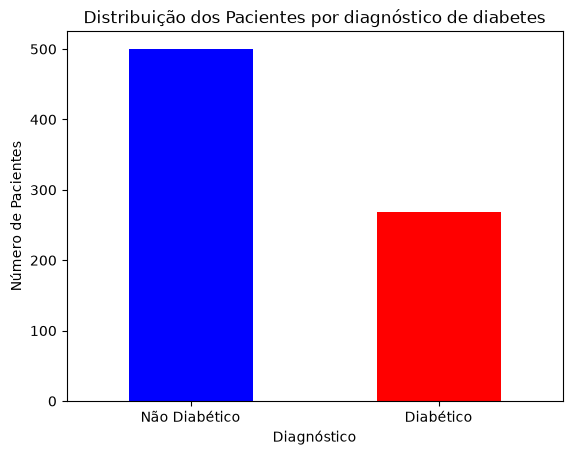

In [3]:
df["Diabetic"].value_counts().plot(kind='bar', color=['blue', 'red'])
plt.xlabel('Diagnóstico')
plt.ylabel('Número de Pacientes')
plt.title('Distribuição dos Pacientes por diagnóstico de diabetes')
plt.xticks(ticks=[0, 1], labels=['Não Diabético', 'Diabético'], rotation=0)
plt.show()

Visualizando a relação de dispersão entre Glucose e BMI (IMC) segundo o diagnóstico

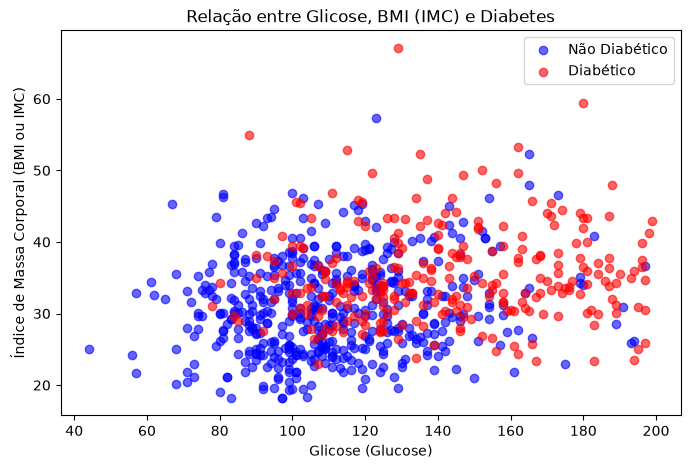

In [4]:
plt.figure(figsize=(8, 5))
plt.scatter(df[df['Diabetic'] == 0]['Glucose'], df[df['Diabetic'] == 0]['BMI'], color='blue', alpha=0.6, label='Não Diabético')
plt.scatter(df[df['Diabetic'] == 1]['Glucose'], df[df['Diabetic'] == 1]['BMI'], color='red', alpha=0.6, label='Diabético')
plt.xlabel('Glicose (Glucose)')
plt.ylabel('Índice de Massa Corporal (BMI ou IMC)')
plt.title('Relação entre Glicose, BMI (IMC) e Diabetes')
plt.legend()
plt.show()

Divisão do conjunto de dados em treino (70%) e teste (30%)

In [5]:
X = df[['Glucose', 'BMI']].values
y = df['Diabetic'].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, stratify=df['Diabetic'], random_state=42) 

print(f"Amostras de treino: {len(X_train)}")
print(f"Amostras de teste: {len(X_test)}")

Amostras de treino: 537
Amostras de teste: 231


Escalonamento das *features*. Essa é uma etapa obrigatória para algoritmos baseados em distância como o KNN. O ajuste do escalonamento será feito apenas no Treino, mas será aplicado nos dados de Treino e Teste. Com isso, será garantido que variáveis de maior magnitude não dominem o cálculo da distância Euclidiana.

Será aplicada a Padronização / Z-score, que transforma os dados de forma que a média de cada coluna se torne 0 e o desvio padrão se torne 1 e é robusto a outliers

In [6]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Treinamento e predição com o modelo KNeighborsClassifier do Scikit-Learn utilizando $k=7$ (o correto seria realizar *Hyperparameter Tuning*, como com K-Fold Cross-Validation / validação cruzada, para encontrar o valor mais adequado de $k$)

In [7]:
knn_model = KNeighborsClassifier(n_neighbors=7)
knn_model.fit(X_train_scaled, y_train)

y_pred = knn_model.predict(X_test_scaled)
acc = accuracy_score(y_test, y_pred)

print(f"Acurácia no conjunto de teste (Scikit-Learn, k=7): {acc * 100:.2f}%")

Acurácia no conjunto de teste (Scikit-Learn, k=7): 72.73%


Relatório de classificação e Matriz de confusão

In [8]:
print("\nRelatório de Classificação:")
print(classification_report(y_test, y_pred, target_names=['Não Diabético', 'Diabético']))

print("Matriz de Confusão:")
print(confusion_matrix(y_test, y_pred))


Relatório de Classificação:
               precision    recall  f1-score   support

Não Diabético       0.76      0.85      0.80       150
    Diabético       0.65      0.49      0.56        81

     accuracy                           0.73       231
    macro avg       0.70      0.67      0.68       231
 weighted avg       0.72      0.73      0.72       231

Matriz de Confusão:
[[128  22]
 [ 41  40]]


## 14. Exemplo prático simples construído do zero (*From Scratch*)

Em vez de otimizar derivadas para achar o Gradiente Descendente como fizemos nas regressões paramétricas, a implementação do KNN puramente exige cálculos vetorizados de distâncias utilizando Álgebra Linear e contagem de vizinhos mais próximos. Serão utilizados os mesmos dados da seção anterior (**13.**)

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from collections import Counter
from sklearn.model_selection import train_test_split

In [10]:
data_path = Path("../data/diabetes.csv")
df = pd.read_csv(data_path, usecols=['Glucose', 'BMI', 'Outcome'])

df = df[(df['Glucose'] > 0) & (df['BMI'] > 0)]
df.rename(columns={'Outcome': 'Diabetic'}, inplace=True)

In [11]:
X = df[['Glucose', 'BMI']].values
y = df['Diabetic'].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, stratify=df['Diabetic'], random_state=42) 

In [12]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

A função para cálculo da distância euclidiana entre dois pontos será definida.

In [13]:
def euclidean_distance(a, b):
    return np.sqrt(np.sum((a - b) ** 2))

Agora, a classe representando o algoritmo KNN será definida.

In [14]:
class KNN:
    def __init__(self, k=3): # por padrão, será considerado k=3 vizinhos mais próximos
        self.k = k

    def fit(self, X, y): # "treinar" em KNN simplesmente armazena os pontos de treino
        self.X_train = X
        self.y_train = y
    
    def _predict(self, point):
        distances = [euclidean_distance(point, train_point) for train_point in self.X_train] # calcula a distância desse ponto para todos os pontos de treino
        k_nearest_indices = np.argsort(distances)[:self.k] # obter os índices dos k vizinhos mais próximos (diz em qual posição os índices dos valores do array original (distances) ficariam se fossem ordenados, do menor para o maior, ex: índice i ficaria na posição j se o array fosse ordenado)
        k_nearest_classes = [self.y_train[i] for i in k_nearest_indices] # obter as classes dos k vizinhos mais próximos

        most_common_class = Counter(k_nearest_classes).most_common(1)[0][0] # retorna a classe mais comum entre os k vizinhos mais próximos

        return most_common_class

    def predict(self, points):
        predictions = [self._predict(point) for point in points]
        return np.array(predictions)

Treinando a implementação *from scratch* do KNN com o conjunto de dados escalonado e k = 7 vizinhos.

In [15]:
knn = KNN(k=7)
knn.fit(X_train_scaled, y_train)

Realizando as predições no conjunto de teste e comparando a acurácia obtida com a obtida utilizando Scikit-Learn no mesmo conjunto de dados

In [16]:
y_pred_scratch = knn.predict(X_test_scaled)
acc_scratch = np.mean(y_pred_scratch == y_test)

print(f"Acurácia do nosso KNN do zero (k={knn.k}): {acc_scratch * 100:.2f}%")
print(f"Resultado igual ao Scikit-Learn? {'Sim' if acc_scratch == acc else 'Não'}")

Acurácia do nosso KNN do zero (k=7): 72.73%
Resultado igual ao Scikit-Learn? Sim


Realizando um teste para verificar o melhor valor para $k$ baseado na acurácia. Serão considerados valores de 1 até 40.

(o correto seria utilizar um conjunto de treino e validação para isso, e utilizar o teste somente uma vez, mas isso é apenas uma verificação)

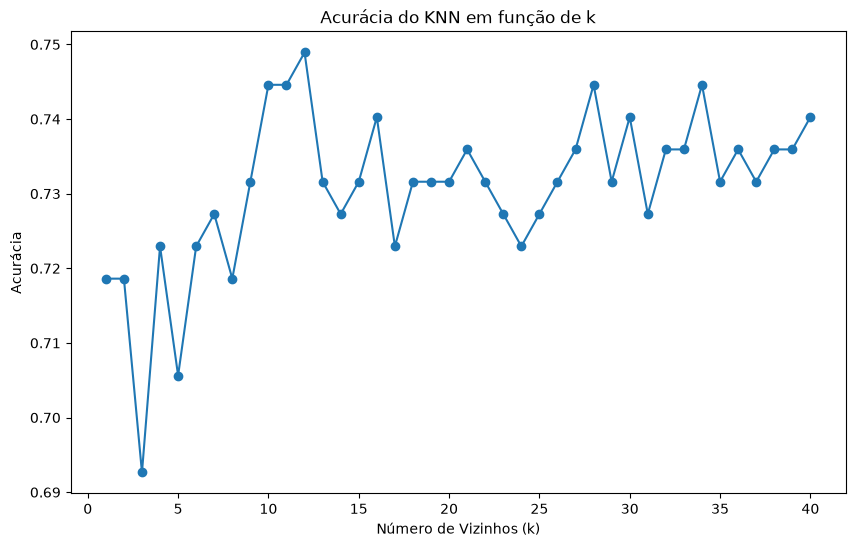

O melhor valor de k é: 12 com acurácia de 74.89%


In [ ]:
max_k = 40
accs = []

for k in range(1, max_k + 1):
    knn = KNN(k=k)
    knn.fit(X_train_scaled, y_train)
    y_pred = knn.predict(X_test_scaled)
    acc = np.mean(y_pred == y_test)
    accs.append(acc)

plt.figure(figsize=(10, 6))
plt.plot(range(1, max_k + 1), accs, marker='o')
plt.title('Acurácia do KNN em função de k')
plt.xlabel('Número de Vizinhos (k)')
plt.ylabel('Acurácia')
plt.show()

best_k = np.argmax(accs) + 1
print(f"O melhor valor de k é: {best_k} com acurácia de {accs[best_k - 1] * 100:.2f}%")

## 15. Conclusão

O **KNN** é um algoritmo não-paramétrico poderoso pela sua simplicidade e capacidade de traçar fronteiras não-lineares. Por ser um modelo *lazy learning*, ele transfere todo o custo computacional para a etapa de inferência / predição ($\mathcal{O}(nd)$), dispensando uma fase formal de otimização de parâmetros.

**Para o uso prático, lembre-se de 3 regras inegociáveis:**

1. **Escalonamento é obrigatório:** Sempre escalone as *features* (ex: padronização com `StandardScaler`) para que magnitudes maiores não dominem o cálculo de distância.
2. **Otimização de $k$:** Valores muito baixos causam *overfitting* (memorização de ruídos); valores muito altos causam *underfitting*. Ajuste via validação cruzada.
3. **Maldição da Dimensionalidade:** Em espaços com muitas variáveis, o conceito matemático de distância perde sentido. Aplique redução de dimensionalidade (ex: PCA) se $d$ for muito grande, ou faça seleção manual das variáveis mais importantes.

Por sua interpretabilidade geométrica, o KNN serve perfeitamente como um **modelo de *baseline*** rápido antes de partir para arquiteturas mais complexas.